Columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


C:\Users\saura\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Visualization saved as kmeans_iris.png


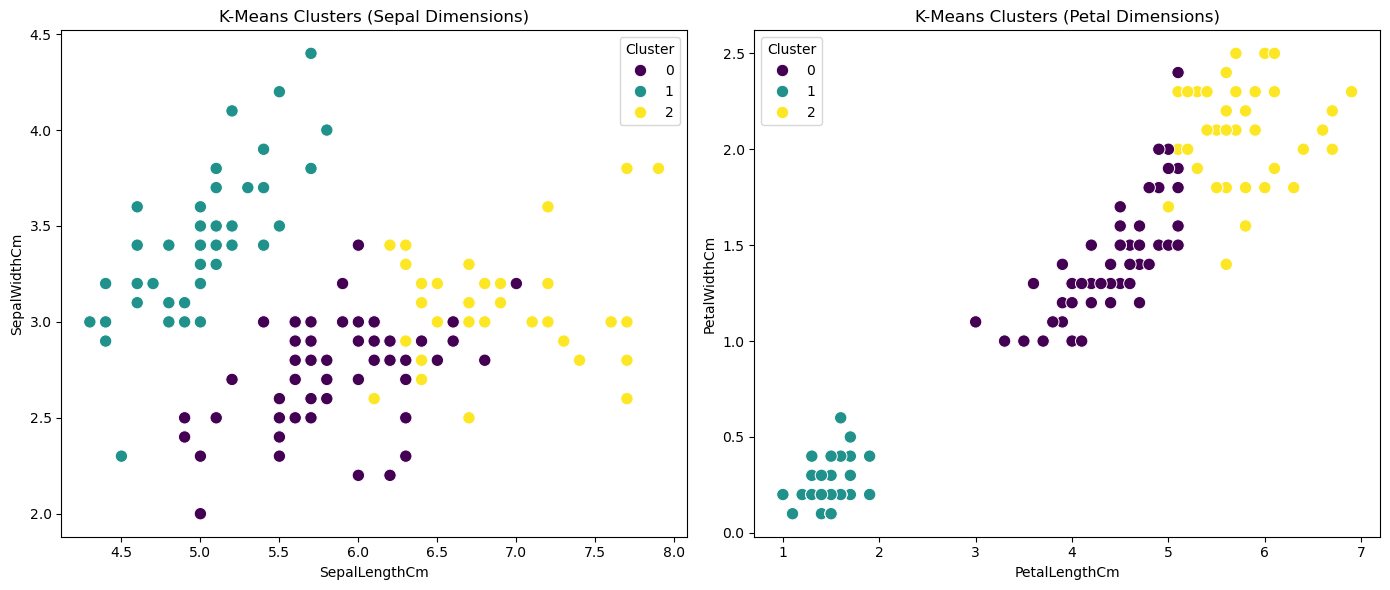

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import os

# Load the dataset
try:
    df = pd.read_csv('Iris.csv')
    print("Columns:", df.columns.tolist())
    
    # Check if 'Id' and 'Species' exist to drop them for clustering
    features = df.copy()
    if 'Id' in features.columns:
        features = features.drop('Id', axis=1)
    if 'Species' in features.columns:
        features = features.drop('Species', axis=1)
        
    # Perform K-Means clustering (k=3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(features)
    
    # Add cluster labels to the dataframe for visualization
    df['Cluster'] = clusters
    
    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: Sepal Length vs Sepal Width
    sns.scatterplot(
        ax=axes[0],
        x=df.columns[1] if 'Id' in df.columns else df.columns[0], 
        y=df.columns[2] if 'Id' in df.columns else df.columns[1],
        hue='Cluster', data=df, palette='viridis', s=80
    )
    axes[0].set_title('K-Means Clusters (Sepal Dimensions)')
    
    # Subplot 2: Petal Length vs Petal Width
    sns.scatterplot(
        ax=axes[1],
        x=df.columns[3] if 'Id' in df.columns else df.columns[2], 
        y=df.columns[4] if 'Id' in df.columns else df.columns[3],
        hue='Cluster', data=df, palette='viridis', s=80
    )
    axes[1].set_title('K-Means Clusters (Petal Dimensions)')
    
    plt.tight_layout()
    plt.savefig('kmeans_iris.png')
    print("Visualization saved as kmeans_iris.png")
    
except Exception as e:
    print(f"Error: {e}")